In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
master = pd.read_csv(
    "featured_dataset_v2.csv"
)

print(master.shape)

(2134080, 38)


In [3]:
sample_df = master.sample(
    n=200000,
    random_state=42
)

print(sample_df.shape)

(200000, 38)


In [4]:
features = [

    "hour",
    "weekday",
    "month",

    "weekend",
    "peak_hour",

    "price",

    "duration",

    "count",

    "fast_ratio",

    "occupancy_density",

    "charger_mix",

    "CBD"
]

In [5]:
target = "utilization_rate"

In [6]:
X = sample_df[
    features
]

y = sample_df[
    target
]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [8]:
rf = RandomForestRegressor(

    n_estimators=100,

    max_depth=15,

    random_state=42,

    n_jobs=-1
)

rf.fit(

    X_train,

    y_train
)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [9]:
predicted_utilization = rf.predict(
    X_test
)

In [10]:
mae = mean_absolute_error(
    y_test,
    predicted_utilization
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_utilization
    )
)

r2 = r2_score(
    y_test,
    predicted_utilization
)

print("MAE =", mae)

print("RMSE =", rmse)

print("R² =", r2)

MAE = 0.006753606769945006
RMSE = 0.014367004049772508
R² = 0.9933080421973293


In [11]:
evaluation = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R²"
    ],

    "Value":[
        mae,
        rmse,
        r2
    ]
})

evaluation

,Metric,Value
0,MAE,0.006754
1,RMSE,0.014367
2,R²,0.993308


In [12]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance

,Feature,Importance
6,duration,0.385104
7,count,0.244694
9,occupancy_density,0.172541
5,price,0.112670
10,charger_mix,0.048978
8,fast_ratio,0.031332
11,CBD,0.003611
2,month,0.000480
0,hour,0.000387
1,weekday,0.000145


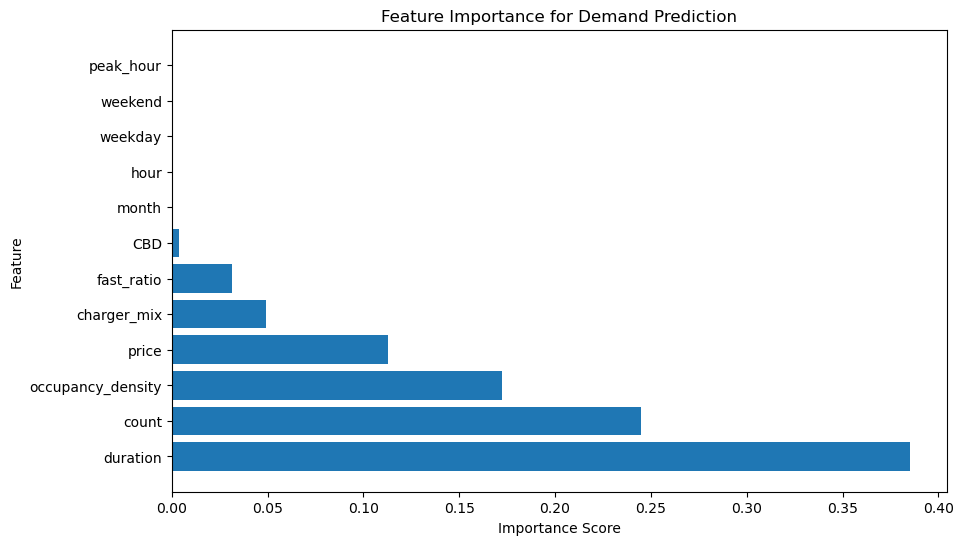

In [13]:
plt.figure(
    figsize=(10,6)
)

plt.barh(

    importance["Feature"],

    importance["Importance"]
)

plt.title(
    "Feature Importance for Demand Prediction"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [14]:
master[
    "predicted_utilization"
] = rf.predict(
    master[features]
)

In [15]:
master[
    "expected_charging_load"
] = (

    master[
        "predicted_utilization"
    ]

    *

    master[
        "count"
    ]
)

In [16]:
master[
    "expected_charging_load"
] = (

    master[
        "predicted_utilization"
    ]

    *

    master[
        "count"
    ]
)

In [17]:
master[
    "congestion_probability"
] = (

    master[
        "predicted_utilization"
    ]

    / 0.80
)

In [18]:
master[
    "congestion_probability"
] = master[
    "congestion_probability"
].clip(
    upper=1
)

In [19]:
master[
[
    "predicted_utilization",

    "expected_charging_load",

    "congestion_probability"
]
].head()

,predicted_utilization,expected_charging_load,congestion_probability
0,0.339068,10.172039,0.423835
1,0.400698,12.020937,0.500872
2,0.400698,12.020937,0.500872
3,0.400698,12.020937,0.500872
4,0.400698,12.020937,0.500872


In [21]:
master.to_csv(

    "agent1_output.csv",

    index=False
)

In [22]:
demand_metrics = pd.DataFrame({

    "Metric":[
        "MAE",
        "RMSE",
        "R2"
    ],

    "Value":[
        mae,
        rmse,
        r2
    ]
})

demand_metrics.to_csv(
    "demand_metrics.csv",
    index=False
)

demand_metrics

,Metric,Value
0,MAE,0.006754
1,RMSE,0.014367
2,R2,0.993308
